In [1]:
import xarray as xr
import numpy as np
import colormaps as cmaps

In [2]:
tau_base = xr.open_dataset("/home/druijsch/LPJmL5/dev15oct2025/config_files/2026_04_23_global_droughtexp_10years/tau_baseline_v3.nc").FPC#.__xarray_dataarray_variable__
tau_DM = xr.open_dataset("/home/druijsch/LPJmL5/dev15oct2025/config_files/2026_04_23_global_droughtexp_10years/tau_dm_v3.nc").FPC#.__xarray_dataarray_variable__
tau_base

<xarray.DataArray 'FPC' (pft: 8, lat: 1397, lon: 3600)> Size: 322MB
[40233600 values with dtype=float64]
Coordinates:
  * pft      (pft) int32 32B 0 1 2 3 4 5 6 7
  * lat      (lat) float64 11kB -55.95 -55.85 -55.75 ... 83.45 83.55 83.65
  * lon      (lon) float64 29kB -179.9 -179.8 -179.8 ... 179.8 179.9 180.0
Attributes:
    standard_name:  FPC
    long_name:      foliage projected cover

In [3]:
# --- Prepare data ---
tau_base_mean = tau_base.where(tau_base < 120).where(tau_base > 0).mean(dim='pft')
tau_DM_mean   = tau_DM.where(tau_DM < 120).where(tau_DM > 0).mean(dim='pft')

/scratch-local/77370/ipykernel_411467/1362993496.py:37: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


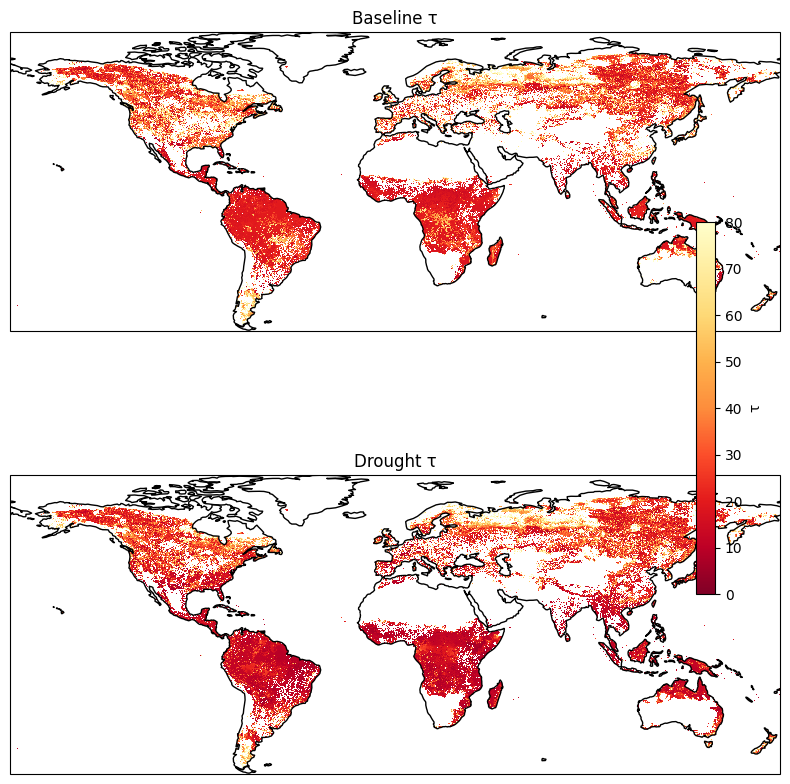

In [18]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

# --- Figure with 2 rows ---
fig, axes = plt.subplots(
    nrows=2, ncols=1,
    figsize=(8, 10),
    subplot_kw={'projection': ccrs.PlateCarree()}
)

# --- Baseline map ---
tau_base_mean.plot(
    ax=axes[0],
    transform=ccrs.PlateCarree(),
    vmin=0, vmax=80,
    cmap="YlOrRd_r",
    add_colorbar=False
)
axes[0].coastlines()
axes[0].set_title("Baseline τ")

# --- Drought map ---
im = tau_DM_mean.plot(
    ax=axes[1],
    transform=ccrs.PlateCarree(),
    vmin=0, vmax=80,
    cmap="YlOrRd_r",
    add_colorbar=False
)
axes[1].coastlines()
axes[1].set_title("Drought τ")

# --- One shared colorbar ---
cbar = fig.colorbar(im, ax=axes, orientation='vertical', fraction=0.03, pad=0.02)
cbar.set_label("τ")

plt.tight_layout()
plt.show()

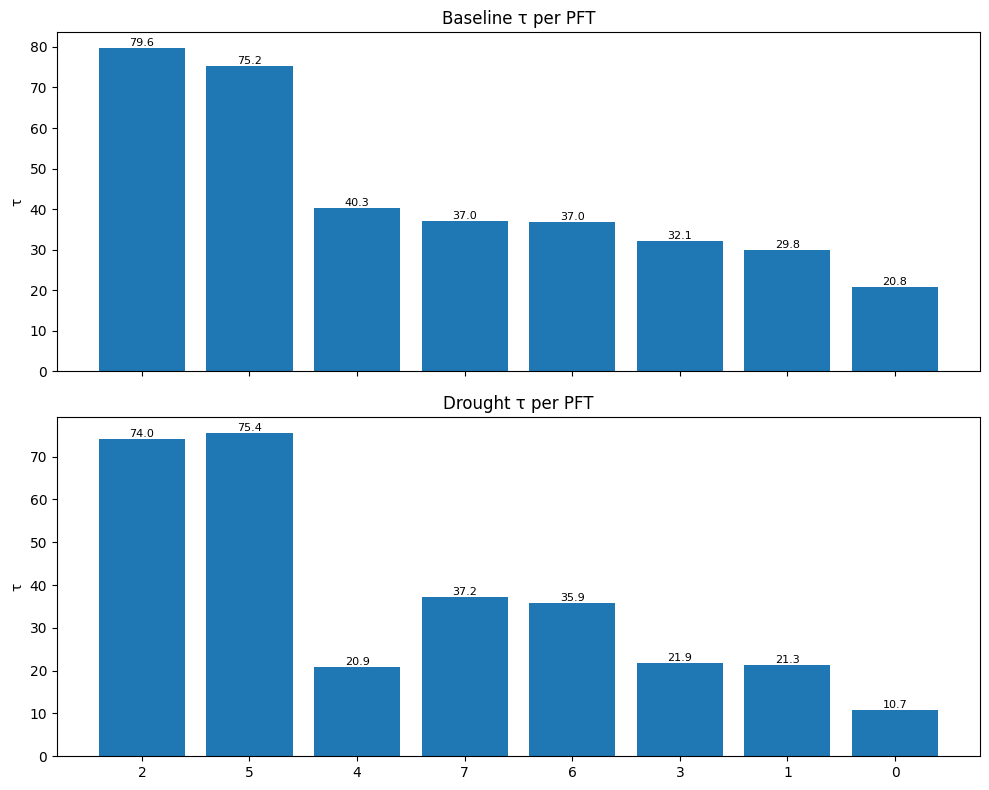

In [19]:
import matplotlib.pyplot as plt
import numpy as np

# --- Clean data ---
tau_base_clean = tau_base.where((tau_base > 0) & (tau_base < 120))
tau_DM_clean   = tau_DM.where((tau_DM > 0) & (tau_DM < 120))

# --- Mean per PFT (global mean) ---
base_pft = tau_base_clean.mean(dim=['lat', 'lon'])
dm_pft   = tau_DM_clean.mean(dim=['lat', 'lon'])

pfts = base_pft['pft'].values
base_vals = base_pft.values
dm_vals   = dm_pft.values

# --- Optional: sort by baseline (makes it easier to read) ---
order = np.argsort(base_vals)[::-1]
pfts = pfts[order]
base_vals = base_vals[order]
dm_vals = dm_vals[order]

# --- Plot ---
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

x = np.arange(len(pfts))

# --- Baseline ---
axes[0].bar(x, base_vals)
axes[0].set_title("Baseline τ per PFT")
axes[0].set_ylabel("τ")

# Add value labels
for i, v in enumerate(base_vals):
    axes[0].text(i, v, f"{v:.1f}", ha='center', va='bottom', fontsize=8)

# --- Drought ---
axes[1].bar(x, dm_vals)
axes[1].set_title("Drought τ per PFT")
axes[1].set_ylabel("τ")

for i, v in enumerate(dm_vals):
    axes[1].text(i, v, f"{v:.1f}", ha='center', va='bottom', fontsize=8)

# --- X-axis ---
axes[1].set_xticks(x)
axes[1].set_xticklabels(pfts)

plt.tight_layout()
plt.show()

/scratch-local/77370/ipykernel_411467/2344262424.py:59: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


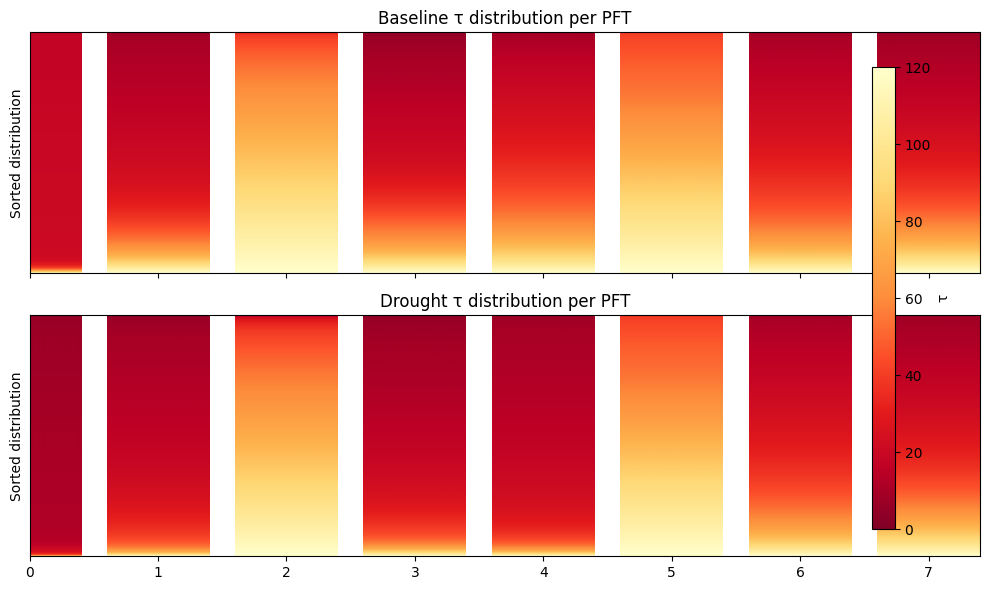

In [20]:
import matplotlib.pyplot as plt
import numpy as np

# --- Clean data ---
tau_base_clean = tau_base.where((tau_base > 0) & (tau_base < 120))
tau_DM_clean   = tau_DM.where((tau_DM > 0) & (tau_DM < 120))

pfts = tau_base_clean['pft'].values
n_pft = len(pfts)

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

def plot_colorbars(ax, data, title):
    for i, pft in enumerate(pfts):
        # Select PFT and flatten spatial dims
        vals = data.sel(pft=pft).values.flatten()
        vals = vals[~np.isnan(vals)]

        if len(vals) == 0:
            continue

        # Sort values
        vals_sorted = np.sort(vals)

        # Make it a 2D array for imshow (vertical strip)
        strip = vals_sorted[:, None]

        ax.imshow(
            strip,
            aspect='auto',
            cmap="YlOrRd_r",
            vmin=0,
            vmax=120,
            extent=(i - 0.4, i + 0.4, 0, 1)  # x-position of the "bar"
        )

    ax.set_title(title)
    ax.set_ylabel("Sorted distribution")
    ax.set_yticks([])

# --- Plot both panels ---
plot_colorbars(axes[0], tau_base_clean, "Baseline τ distribution per PFT")
plot_colorbars(axes[1], tau_DM_clean,   "Drought τ distribution per PFT")

# --- X axis ---
axes[1].set_xticks(np.arange(n_pft))
axes[1].set_xticklabels(pfts)

# --- Colorbar ---
cbar = fig.colorbar(
    plt.cm.ScalarMappable(cmap="YlOrRd_r", norm=plt.Normalize(0, 120)),
    ax=axes,
    orientation='vertical',
    fraction=0.03,
    pad=0.02
)
cbar.set_label("τ")

plt.tight_layout()
plt.show()

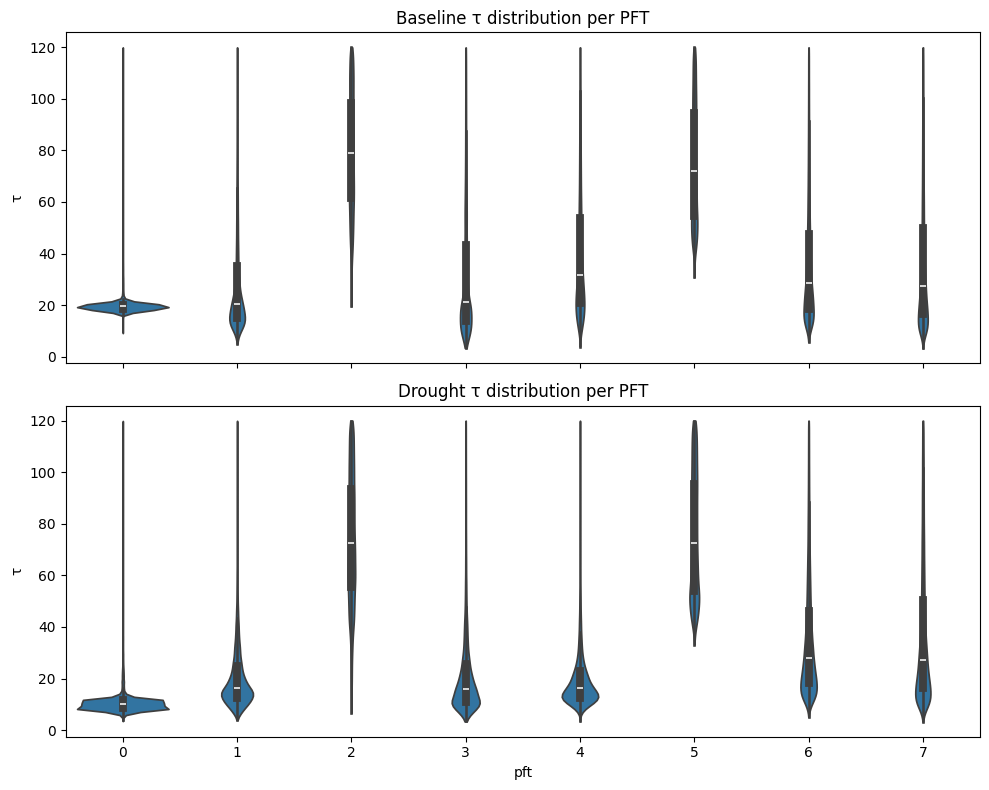

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# --- Clean data ---
tau_base_clean = tau_base.where((tau_base > 0) & (tau_base < 120))
tau_DM_clean   = tau_DM.where((tau_DM > 0) & (tau_DM < 120))

pfts = tau_base_clean['pft'].values

# --- Convert to long dataframe ---
def to_dataframe(data, label):
    dfs = []
    for pft in pfts:
        vals = data.sel(pft=pft).values.flatten()
        vals = vals[~np.isnan(vals)]
        
        df = pd.DataFrame({
            "tau": vals,
            "pft": pft,
            "scenario": label
        })
        dfs.append(df)
    return pd.concat(dfs, ignore_index=True)

df_base = to_dataframe(tau_base_clean, "Baseline")
df_dm   = to_dataframe(tau_DM_clean, "Drought")

# --- Plot ---
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Baseline
sns.violinplot(
    data=df_base,
    x="pft", y="tau",
    ax=axes[0],
    cut=0
)
axes[0].set_title("Baseline τ distribution per PFT")
axes[0].set_ylabel("τ")

# Drought
sns.violinplot(
    data=df_dm,
    x="pft", y="tau",
    ax=axes[1],
    cut=0
)
axes[1].set_title("Drought τ distribution per PFT")
axes[1].set_ylabel("τ")

plt.tight_layout()
plt.show()

/scratch-local/77370/ipykernel_411467/2207281791.py:74: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


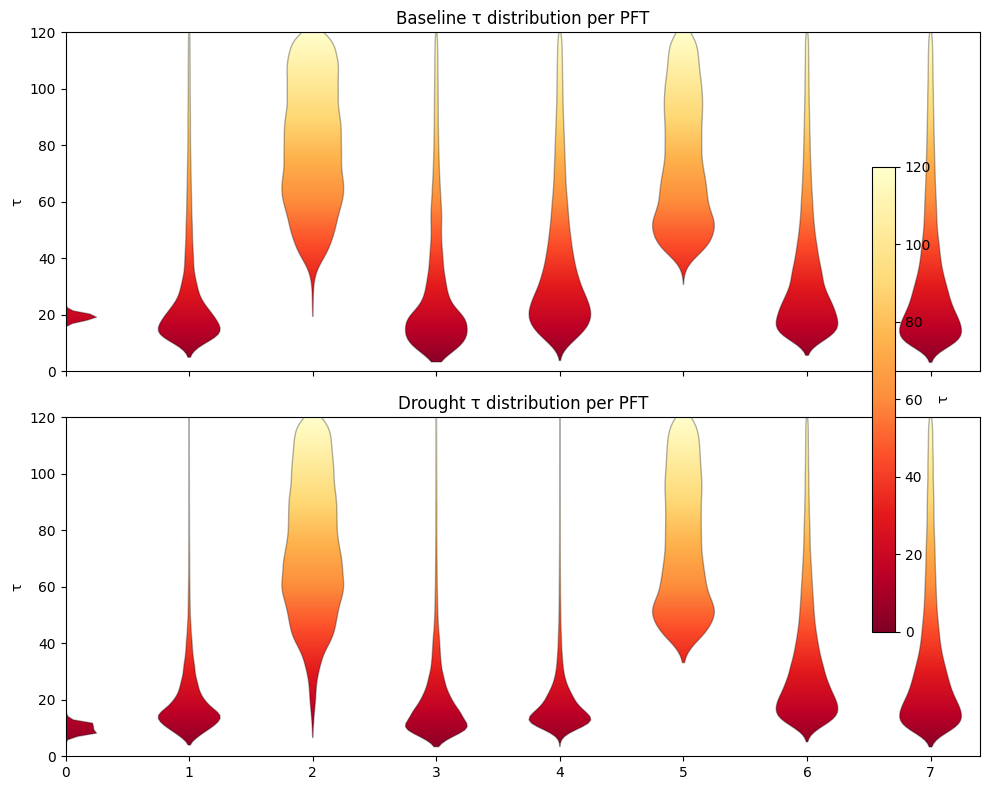

In [24]:
import matplotlib.pyplot as plt
import numpy as np
import colormaps as cmaps

# --- Clean data ---
tau_base_clean = tau_base.where((tau_base > 0) & (tau_base < 120))
tau_DM_clean   = tau_DM.where((tau_DM > 0) & (tau_DM < 120))

pfts = tau_base_clean['pft'].values

# --- helper function ---
def get_pft_data(data):
    out = []
    for pft in pfts:
        vals = data.sel(pft=pft).values.flatten()
        vals = vals[~np.isnan(vals)]
        out.append(vals)
    return out

base_data = get_pft_data(tau_base_clean)
dm_data   = get_pft_data(tau_DM_clean)

# --- colormap ---
cmap = plt.get_cmap("YlOrRd_r")
cmap = cmaps.gui_default
norm = plt.Normalize(0, 120)

# --- figure ---
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

def draw(ax, data, title):
    parts = ax.violinplot(
        data,
        positions=np.arange(len(pfts)),
        showextrema=False
    )

    for i, body in enumerate(parts['bodies']):
        body.set_facecolor('none')
        body.set_edgecolor('black')

        gradient = np.linspace(0, 120, 256).reshape(-1, 1)

        im = ax.imshow(
            gradient,
            aspect='auto',
            cmap=cmap,
            norm=norm,
            extent=(i - 0.4, i + 0.4, 0, 120),
            origin='lower'
        )

        im.set_clip_path(body.get_paths()[0], transform=ax.transData)

    ax.set_title(title)
    ax.set_ylabel("τ")
    ax.set_ylim(0, 120)

# --- draw both panels ---
draw(axes[0], base_data, "Baseline τ distribution per PFT")
draw(axes[1], dm_data,   "Drought τ distribution per PFT")

# --- x-axis ---
axes[1].set_xticks(np.arange(len(pfts)))
axes[1].set_xticklabels(pfts)

# --- shared colorbar ---
cbar = fig.colorbar(
    plt.cm.ScalarMappable(norm=norm, cmap=cmap),
    ax=axes,
    fraction=0.03,
    pad=0.02
)
cbar.set_label("τ")

plt.tight_layout()
plt.show()

NameError: name 'cmaps' is not defined

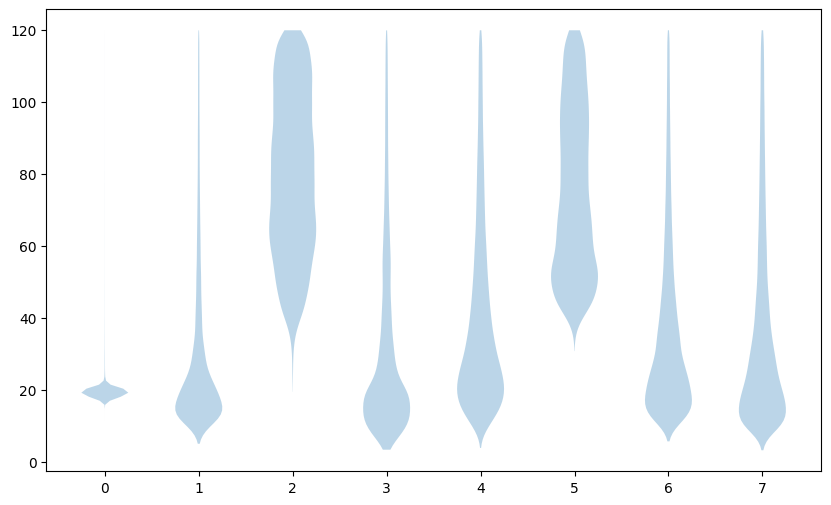

In [26]:
import matplotlib.pyplot as plt
import numpy as np

# --- Clean data ---
tau_base_clean = tau_base.where((tau_base > 0) & (tau_base < 120))

pfts = tau_base_clean['pft'].values

# --- Collect data per PFT ---
data = []
for pft in pfts:
    vals = tau_base_clean.sel(pft=pft).values.flatten()
    vals = vals[~np.isnan(vals)]
    data.append(vals)

# --- Plot ---
fig, ax = plt.subplots(figsize=(10, 6))

parts = ax.violinplot(data, positions=np.arange(len(pfts)), showextrema=False)

# --- Colormap ---
cmap = plt.get_cmap("YlOrRd_r")
cmap = cmaps.gui_default
norm = plt.Normalize(0, 120)

# --- Apply gradient to each violin ---
for i, body in enumerate(parts['bodies']):
    body.set_facecolor('none')  # remove default fill
    body.set_edgecolor('black')

    # vertical gradient
    gradient = np.linspace(0, 120, 256).reshape(-1, 1)

    im = ax.imshow(
        gradient,
        aspect='auto',
        cmap=cmap,
        norm=norm,
        extent=(i - 0.4, i + 0.4, 0, 120),
        origin='lower'
    )

    # clip to violin shape
    im.set_clip_path(body.get_paths()[0], transform=ax.transData)

# --- Colorbar ---
cbar = fig.colorbar(
    plt.cm.ScalarMappable(norm=norm, cmap=cmap),
    ax=ax
)
cbar.set_label("τ")

# --- Formatting ---
ax.set_xticks(np.arange(len(pfts)))
ax.set_xticklabels(pfts)
ax.set_ylim(0, 120)
ax.set_title("τ distribution per PFT (gradient violins)")
ax.set_ylabel("τ")
ax.set_xlim(-0.5, 7.5)

plt.tight_layout()
plt.show()

/scratch-local/77370/ipykernel_1187162/3429681527.py:61: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


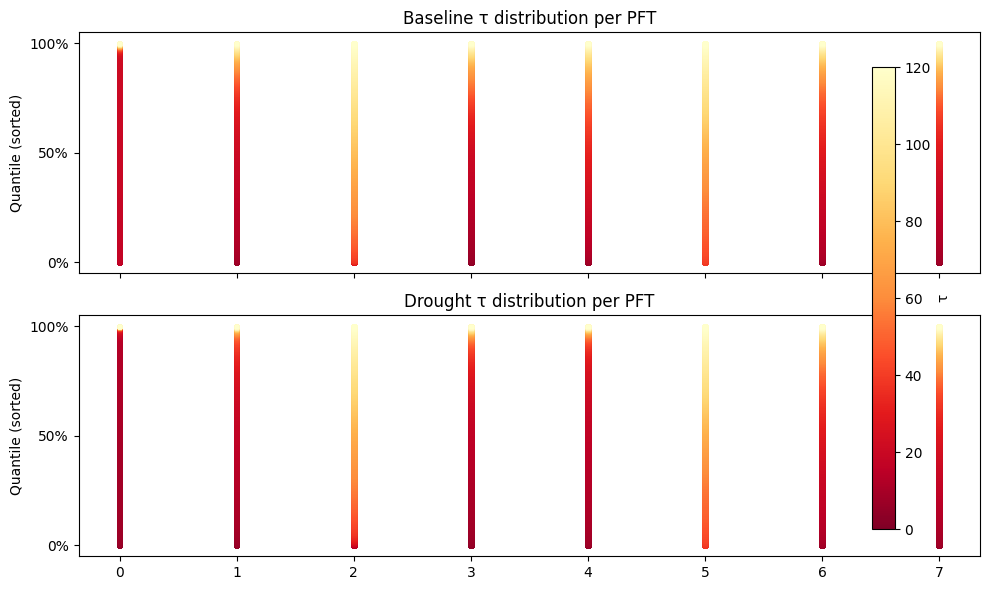

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# --- Clean data ---
tau_base_clean = tau_base.where((tau_base > 0) & (tau_base < 120))
tau_DM_clean   = tau_DM.where((tau_DM > 0) & (tau_DM < 120))

pfts = tau_base_clean['pft'].values

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

cmap = plt.get_cmap("YlOrRd_r")
norm = plt.Normalize(0, 120)

def plot_colorbars(ax, data, title):
    for i, pft in enumerate(pfts):
        vals = data.sel(pft=pft).values.flatten()
        vals = vals[~np.isnan(vals)]

        if len(vals) == 0:
            continue

        vals_sorted = np.sort(vals)
        y = np.linspace(0, 1, len(vals_sorted))

        # --- wider x-band (this is the key change) ---
        x = np.full_like(vals_sorted, i, dtype=float)

        ax.scatter(
            x,
            y,
            c=vals_sorted,
            cmap=cmap,
            norm=norm,
            s=6,              # bigger dots → visually wider block
            marker='s'
        )

    ax.set_title(title)
    ax.set_ylabel("Quantile (sorted)")
    ax.set_yticks([0, 0.5, 1])
    ax.set_yticklabels(["0%", "50%", "100%"])

# --- plots ---
plot_colorbars(axes[0], tau_base_clean, "Baseline τ distribution per PFT")
plot_colorbars(axes[1], tau_DM_clean,   "Drought τ distribution per PFT")

# --- x-axis ---
axes[1].set_xticks(np.arange(len(pfts)))
axes[1].set_xticklabels(pfts)

# --- colorbar ---
cbar = fig.colorbar(
    plt.cm.ScalarMappable(norm=norm, cmap=cmap),
    ax=axes,
    fraction=0.03,
    pad=0.02
)
cbar.set_label("τ")

plt.tight_layout()
plt.show()

/scratch-local/77370/ipykernel_1187162/1508620084.py:16: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_continuous = plt.cm.get_cmap(cmap)


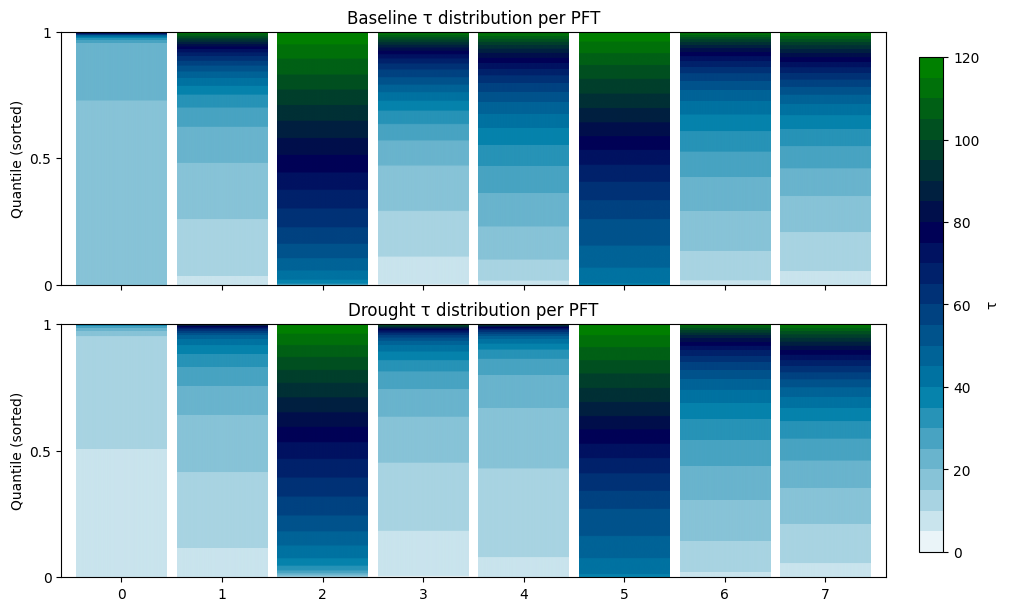

In [23]:
import matplotlib.pyplot as plt
import numpy as np

# --- Clean data ---
tau_base_clean = tau_base.where((tau_base > 0) & (tau_base < 120))
tau_DM_clean   = tau_DM.where((tau_DM > 0) & (tau_DM < 120))

pfts = tau_base_clean['pft'].values
n_pft = len(pfts)

cmap = plt.get_cmap("YlOrRd_r")
cmap = cmaps.roma
cmap = cmaps.gnbu_r

def create_discrete_colormap(cmap, num_colors):
    cmap_continuous = plt.cm.get_cmap(cmap)
    colors_continuous = cmap_continuous(np.linspace(0.03, 1, num_colors))  # Adjusted range, excluding white
    cmap_discrete = plt.matplotlib.colors.ListedColormap(colors_continuous)
    return cmap_discrete

# Example usage:
cmap = create_discrete_colormap("ocean_r", 24)

norm = plt.Normalize(0, 120)

fig, axes = plt.subplots(
    2, 1,
    figsize=(10, 6),
    sharex=True,
    constrained_layout=True
)

def plot_strips(ax, data, title):
    for i, pft in enumerate(pfts):
        vals = data.sel(pft=pft).values.flatten()
        vals = vals[~np.isnan(vals)]

        if len(vals) == 0:
            continue

        vals_sorted = np.sort(vals)
        strip = vals_sorted[:, None]

        ax.imshow(
            strip,
            aspect='auto',
            cmap=cmap,
            norm=norm,
            extent=(i - 0.45, i + 0.45, 0, 1),
            origin='lower'
        )

    ax.set_title(title)
    ax.set_ylabel("Quantile (sorted)")
    ax.set_yticks([0, 0.5, 1])
    ax.set_yticklabels(["0", "0.5", "1"])

    # ✅ FIX 1: prevent clipping of first/last PFT
    ax.set_xlim(-0.6, len(pfts) - 0.4)

# --- plots ---
plot_strips(axes[0], tau_base_clean, "Baseline τ distribution per PFT")
plot_strips(axes[1], tau_DM_clean,   "Drought τ distribution per PFT")

axes[1].set_xticks(np.arange(n_pft))
axes[1].set_xticklabels(pfts)

# --- FIX 2: proper colorbar placement (no overlap) ---
sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

cbar = fig.colorbar(
    sm,
    ax=axes,
    location="right",
    fraction=0.03,
    pad=0.04
)
cbar.set_label("τ")

plt.show()

/scratch-local/77370/ipykernel_1187162/600667670.py:72: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_continuous = plt.cm.get_cmap(cmap)


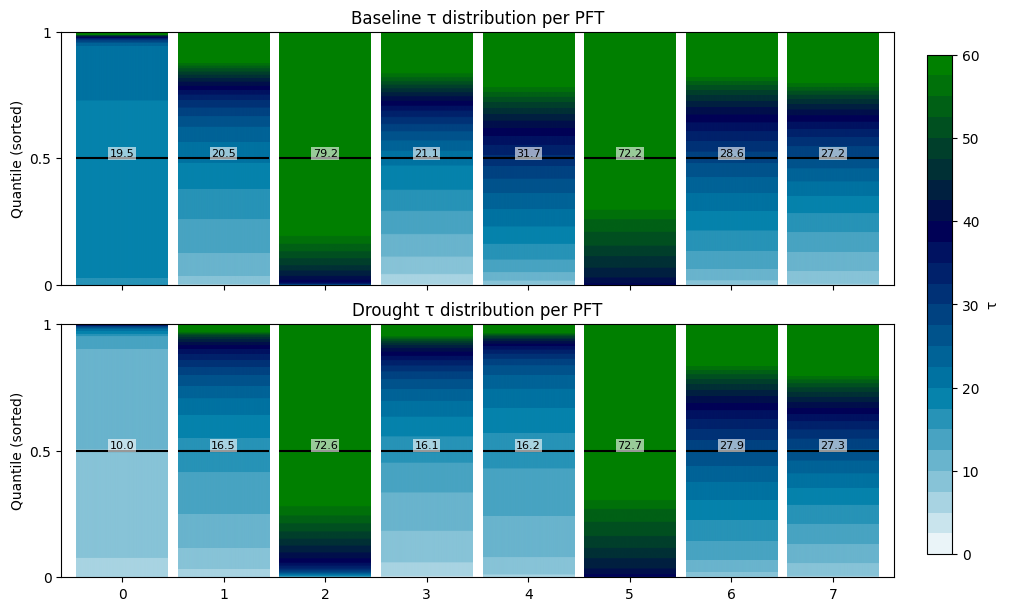

In [29]:
def plot_strips(ax, data, title):
    for i, pft in enumerate(pfts):
        vals = data.sel(pft=pft).values.flatten()
        vals = vals[~np.isnan(vals)]

        if len(vals) == 0:
            continue

        vals_sorted = np.sort(vals)
        strip = vals_sorted[:, None]

        # --- plot distribution ---
        ax.imshow(
            strip,
            aspect='auto',
            cmap=cmap,
            norm=norm,
            extent=(i - 0.45, i + 0.45, 0, 1),
            origin='lower'
        )

        # --- MEDIAN ---
        median = np.median(vals_sorted)

        # map median to quantile axis (0–1)
        y_med = np.searchsorted(vals_sorted, median) / len(vals_sorted)

        # horizontal median line
        ax.hlines(
            y=y_med,
            xmin=i - 0.45,
            xmax=i + 0.45,
            color='black',
            linewidth=1.5
        )

        # median label
        ax.text(
            i,
            y_med,
            f"{median:.1f}",
            ha='center',
            va='bottom',
            fontsize=8,
            color='black',
            bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', pad=1)
        )

    ax.set_title(title)
    ax.set_ylabel("Quantile (sorted)")
    ax.set_yticks([0, 0.5, 1])
    ax.set_yticklabels(["0", "0.5", "1"])

    ax.set_xlim(-0.6, len(pfts) - 0.4)
    
    
import matplotlib.pyplot as plt
import numpy as np

# --- Clean data ---
tau_base_clean = tau_base.where((tau_base > 0) & (tau_base < 120))
tau_DM_clean   = tau_DM.where((tau_DM > 0) & (tau_DM < 120))

pfts = tau_base_clean['pft'].values
n_pft = len(pfts)

cmap = plt.get_cmap("YlOrRd_r")
cmap = cmaps.roma
cmap = cmaps.gnbu_r

def create_discrete_colormap(cmap, num_colors):
    cmap_continuous = plt.cm.get_cmap(cmap)
    colors_continuous = cmap_continuous(np.linspace(0.03, 1, num_colors))  # Adjusted range, excluding white
    cmap_discrete = plt.matplotlib.colors.ListedColormap(colors_continuous)
    return cmap_discrete

# Example usage:
cmap = create_discrete_colormap("ocean_r", 24)

import matplotlib as mpl

class ClipNorm(mpl.colors.Normalize):
    def __init__(self, vmin=None, vmax=None, clip=False):
        super().__init__(vmin, vmax, clip)

    def __call__(self, value, clip=None):
        value = np.array(value)
        value = np.minimum(value, self.vmax)  # <-- key part: clamp
        return super().__call__(value, clip=clip)

norm = ClipNorm(vmin=0, vmax=60)

fig, axes = plt.subplots(
    2, 1,
    figsize=(10, 6),
    sharex=True,
    constrained_layout=True
)

# --- plots ---
plot_strips(axes[0], tau_base_clean, "Baseline τ distribution per PFT")
plot_strips(axes[1], tau_DM_clean,   "Drought τ distribution per PFT")

axes[1].set_xticks(np.arange(n_pft))
axes[1].set_xticklabels(pfts)

# --- FIX 2: proper colorbar placement (no overlap) ---
sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

cbar = fig.colorbar(
    sm,
    ax=axes,
    location="right",
    fraction=0.03,
    pad=0.04
)
cbar.set_label("τ")

plt.show()

/scratch-local/77370/ipykernel_1187162/1223574454.py:37: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


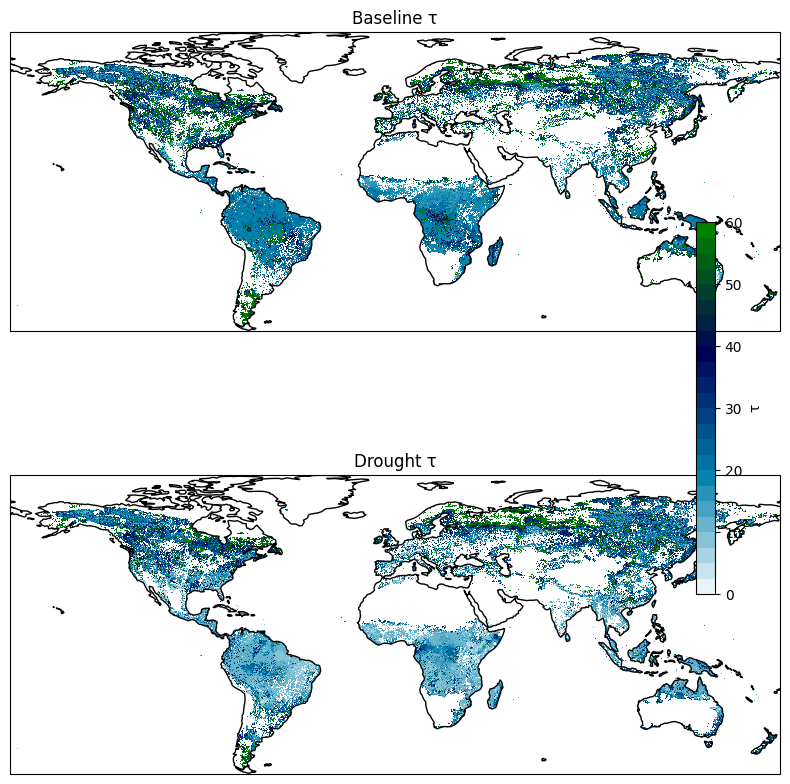

In [27]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

# --- Figure with 2 rows ---
fig, axes = plt.subplots(
    nrows=2, ncols=1,
    figsize=(8, 10),
    subplot_kw={'projection': ccrs.PlateCarree()}
)

# --- Baseline map ---
tau_base_mean.plot(
    ax=axes[0],
    transform=ccrs.PlateCarree(),
    vmin=0, vmax=60,
    cmap=cmap,
    add_colorbar=False
)
axes[0].coastlines()
axes[0].set_title("Baseline τ")

# --- Drought map ---
im = tau_DM_mean.plot(
    ax=axes[1],
    transform=ccrs.PlateCarree(),
    vmin=0, vmax=60,
    cmap=cmap,
    add_colorbar=False
)
axes[1].coastlines()
axes[1].set_title("Drought τ")

# --- One shared colorbar ---
cbar = fig.colorbar(im, ax=axes, orientation='vertical', fraction=0.03, pad=0.02)
cbar.set_label("τ")

plt.tight_layout()
plt.show()

/scratch-local/77370/ipykernel_2434855/1574976084.py:72: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_continuous = plt.cm.get_cmap(cmap)


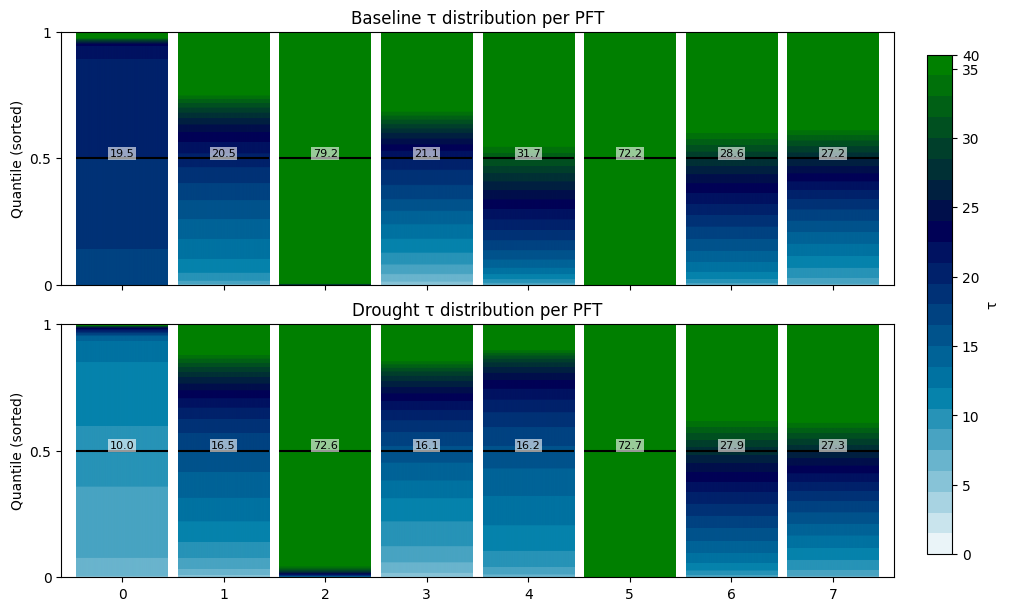

In [12]:
def plot_strips(ax, data, title):
    for i, pft in enumerate(pfts):
        vals = data.sel(pft=pft).values.flatten()
        vals = vals[~np.isnan(vals)]

        if len(vals) == 0:
            continue

        vals_sorted = np.sort(vals)
        strip = vals_sorted[:, None]

        # --- plot distribution ---
        ax.imshow(
            strip,
            aspect='auto',
            cmap=cmap,
            norm=norm,
            extent=(i - 0.45, i + 0.45, 0, 1),
            origin='lower'
        )

        # --- MEDIAN ---
        median = np.median(vals_sorted)

        # map median to quantile axis (0–1)
        y_med = np.searchsorted(vals_sorted, median) / len(vals_sorted)

        # horizontal median line
        ax.hlines(
            y=y_med,
            xmin=i - 0.45,
            xmax=i + 0.45,
            color='black',
            linewidth=1.5
        )

        # median label
        ax.text(
            i,
            y_med,
            f"{median:.1f}",
            ha='center',
            va='bottom',
            fontsize=8,
            color='black',
            bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', pad=1)
        )

    ax.set_title(title)
    ax.set_ylabel("Quantile (sorted)")
    ax.set_yticks([0, 0.5, 1])
    ax.set_yticklabels(["0", "0.5", "1"])

    ax.set_xlim(-0.6, len(pfts) - 0.4)
    
    
import matplotlib.pyplot as plt
import numpy as np

# --- Clean data ---
tau_base_clean = tau_base.where((tau_base > 0) & (tau_base < 120))
tau_DM_clean   = tau_DM.where((tau_DM > 0) & (tau_DM < 120))

pfts = tau_base_clean['pft'].values
n_pft = len(pfts)

cmap = plt.get_cmap("YlOrRd_r")
cmap = cmaps.roma
cmap = cmaps.gnbu_r

def create_discrete_colormap(cmap, num_colors):
    cmap_continuous = plt.cm.get_cmap(cmap)
    colors_continuous = cmap_continuous(np.linspace(0.03, 1, num_colors))  # Adjusted range, excluding white
    cmap_discrete = plt.matplotlib.colors.ListedColormap(colors_continuous)
    return cmap_discrete

# Example usage:
cmap = create_discrete_colormap("ocean_r", 24)

import matplotlib as mpl

class ClipNorm(mpl.colors.Normalize):
    def __init__(self, vmin=None, vmax=None, clip=False):
        super().__init__(vmin, vmax, clip)

    def __call__(self, value, clip=None):
        value = np.array(value)
        value = np.minimum(value, self.vmax)  # <-- key part: clamp
        return super().__call__(value, clip=clip)

norm = ClipNorm(vmin=0, vmax=36)

fig, axes = plt.subplots(
    2, 1,
    figsize=(10, 6),
    sharex=True,
    constrained_layout=True
)

# --- plots ---
plot_strips(axes[0], tau_base_clean, "Baseline τ distribution per PFT")
plot_strips(axes[1], tau_DM_clean,   "Drought τ distribution per PFT")

axes[1].set_xticks(np.arange(n_pft))
axes[1].set_xticklabels(pfts)

# --- FIX 2: proper colorbar placement (no overlap) ---
sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

cbar = fig.colorbar(
    sm,
    ax=axes,
    location="right",
    fraction=0.03,
    pad=0.04
)
cbar.set_label("τ")

plt.show()

/scratch-local/77370/ipykernel_2434855/333198331.py:37: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


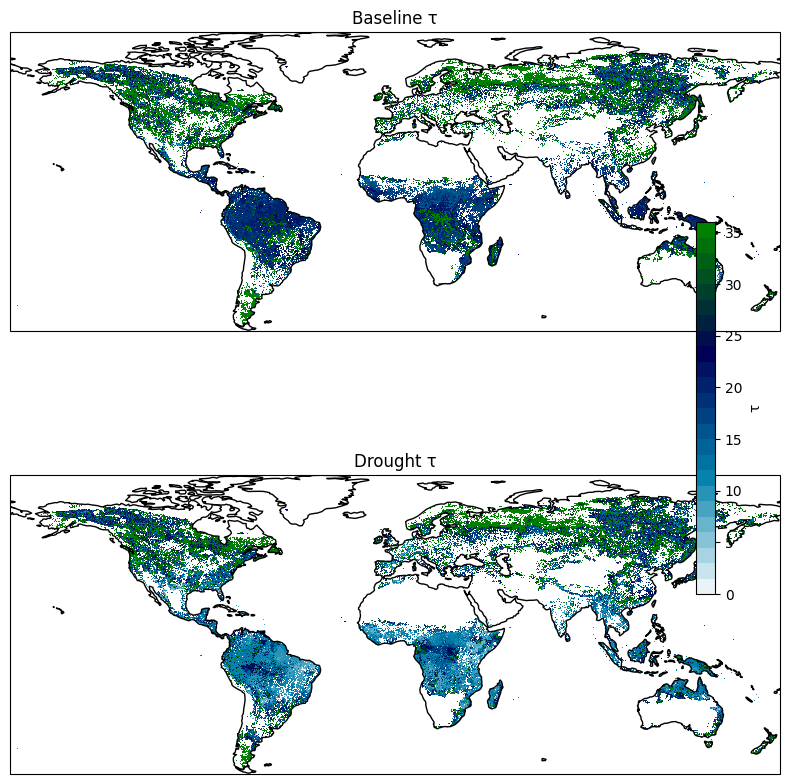

In [13]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

# --- Figure with 2 rows ---
fig, axes = plt.subplots(
    nrows=2, ncols=1,
    figsize=(8, 10),
    subplot_kw={'projection': ccrs.PlateCarree()}
)

# --- Baseline map ---
tau_base_mean.plot(
    ax=axes[0],
    transform=ccrs.PlateCarree(),
    vmin=0, vmax=36,
    cmap=cmap,
    add_colorbar=False
)
axes[0].coastlines()
axes[0].set_title("Baseline τ")

# --- Drought map ---
im = tau_DM_mean.plot(
    ax=axes[1],
    transform=ccrs.PlateCarree(),
    vmin=0, vmax=36,
    cmap=cmap,
    add_colorbar=False
)
axes[1].coastlines()
axes[1].set_title("Drought τ")

# --- One shared colorbar ---
cbar = fig.colorbar(im, ax=axes, orientation='vertical', fraction=0.03, pad=0.02)
cbar.set_label("τ")

plt.tight_layout()
plt.show()

/scratch-local/77370/ipykernel_4000997/1524486087.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_continuous = plt.cm.get_cmap(cmap)


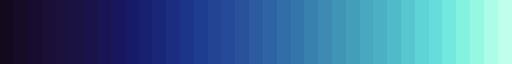

In [6]:

import matplotlib.pyplot as plt
def create_discrete_colormap(cmap, num_colors):
    cmap_continuous = plt.cm.get_cmap(cmap)
    colors_continuous = cmap_continuous(np.linspace(0.03, 1, num_colors))  # Adjusted range, excluding white
    cmap_discrete = plt.matplotlib.colors.ListedColormap(colors_continuous)
    return cmap_discrete

# Example usage:
cmap = create_discrete_colormap(cmaps.blue_bl111, 37)
cmap

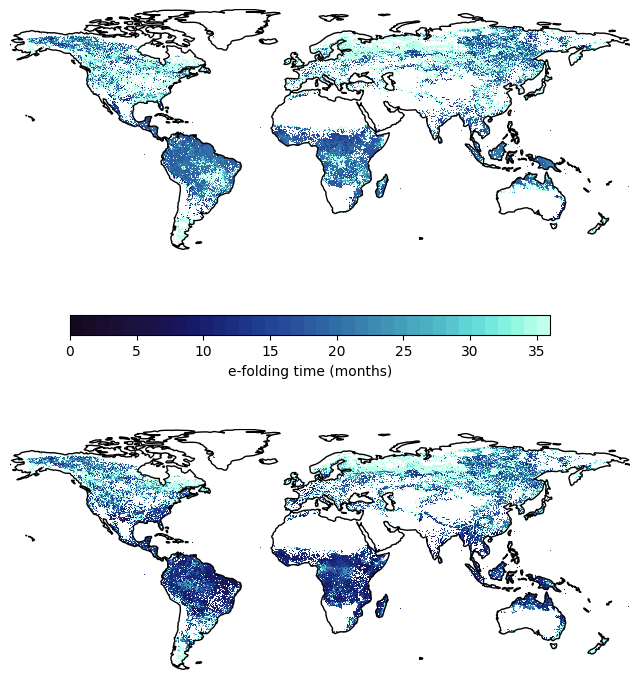

In [22]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs


# --- Figure ---
fig, axes = plt.subplots(
    nrows=2, ncols=1,
    figsize=(8, 10),
    subplot_kw={'projection': ccrs.PlateCarree(central_longitude=11)}
)

# --- Baseline map ---
tau_base_mean.plot(
    ax=axes[0],
    transform=ccrs.PlateCarree(),
    vmin=0, vmax=36,
    cmap=cmap,
    add_colorbar=False
)

# --- Drought map ---
im = tau_DM_mean.plot(
    ax=axes[1],
    transform=ccrs.PlateCarree(),
    vmin=0, vmax=36,
    cmap=cmap,
    add_colorbar=False
)

# --- Coastlines + remove all frames/titles ---
for ax in axes:
    ax.coastlines()
    ax.set_title("")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_frame_on(False)

# --- Horizontal colorbar in middle ---
cbar_ax = fig.add_axes([0.2, 0.5, 0.6, 0.02])  # [left, bottom, width, height]
cbar = fig.colorbar(im, cax=cbar_ax, orientation='horizontal')
cbar.set_label("e-folding time (months)")

# --- Transparent background ---
fig.patch.set_alpha(0)
for ax in axes:
    ax.set_facecolor("none")

# --- Save (transparent) ---
plt.savefig("/home/druijsch/LPJmL5/dev15oct2025/config_files/2026_04_23_global_droughtexp_10years/tau_maps.png", dpi=300, bbox_inches="tight", transparent=True)

plt.show()

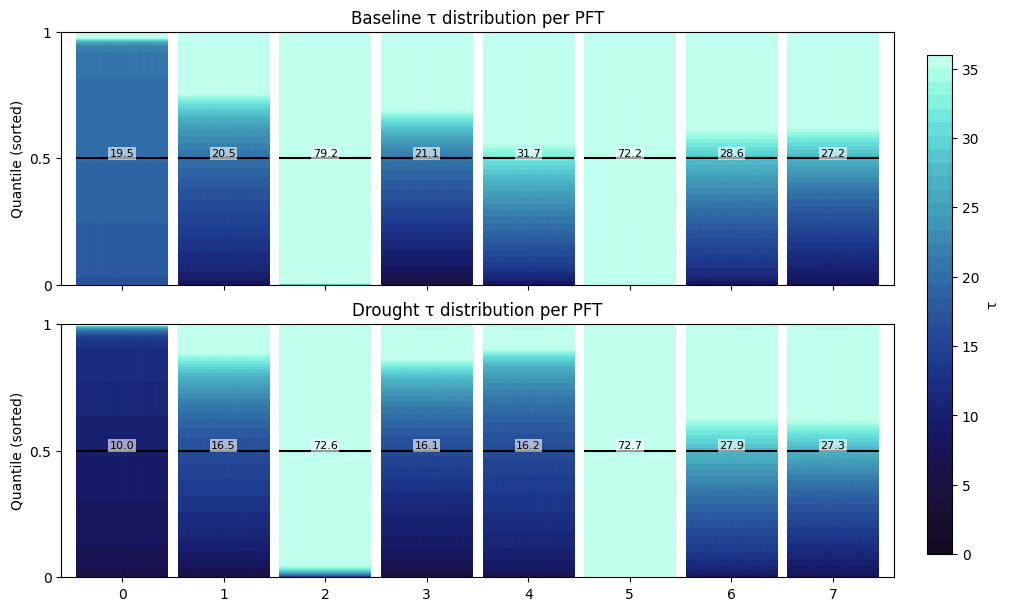

In [ ]:
def plot_strips(ax, data, title):
    for i, pft in enumerate(pfts):
        vals = data.sel(pft=pft).values.flatten()
        vals = vals[~np.isnan(vals)]

        if len(vals) == 0:
            continue

        vals_sorted = np.sort(vals)
        strip = vals_sorted[:, None]

        # --- plot distribution ---
        ax.imshow(
            strip,
            aspect='auto',
            cmap=cmap,
            norm=norm,
            extent=(i - 0.45, i + 0.45, 0, 1),
            origin='lower'
        )

        # --- MEDIAN ---
        median = np.median(vals_sorted)

        # map median to quantile axis (0–1)
        y_med = np.searchsorted(vals_sorted, median) / len(vals_sorted)

        # horizontal median line
        ax.hlines(
            y=y_med,
            xmin=i - 0.45,
            xmax=i + 0.45,
            color='black',
            linewidth=1.5
        )

        # median label
        ax.text(
            i,
            y_med,
            f"{median:.1f}",
            ha='center',
            va='bottom',
            fontsize=8,
            color='black',
            bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', pad=1)
        )

    ax.set_title(title)
    ax.set_ylabel("Quantile (sorted)")
    ax.set_yticks([0, 0.5, 1])
    ax.set_yticklabels(["0", "0.5", "1"])
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_xlim(-0.6, len(pfts) - 0.4)
    



import matplotlib.pyplot as plt
import numpy as np

# --- Clean data ---
tau_base_clean = tau_base.where((tau_base > 0) & (tau_base < 120))
tau_DM_clean   = tau_DM.where((tau_DM > 0) & (tau_DM < 120))



norm = plt.Normalize(0, 36)

pfts = tau_base_clean['pft'].values
n_pft = len(pfts)

import matplotlib as mpl

fig, axes = plt.subplots(
    2, 1,
    figsize=(10, 6),
    sharex=True,
    constrained_layout=True
)

# --- plots ---
plot_strips(axes[0], tau_base_clean, "Baseline τ distribution per PFT")
plot_strips(axes[1], tau_DM_clean,   "Drought τ distribution per PFT")

axes[1].set_xticks(np.arange(n_pft))
axes[1].set_xticklabels(pfts)

# --- FIX 2: proper colorbar placement (no overlap) ---
sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

cbar = fig.colorbar(
    sm,
    ax=axes,
    location="right",
    fraction=0.03,
    pad=0.04
)
cbar.set_label("τ")

plt.show()

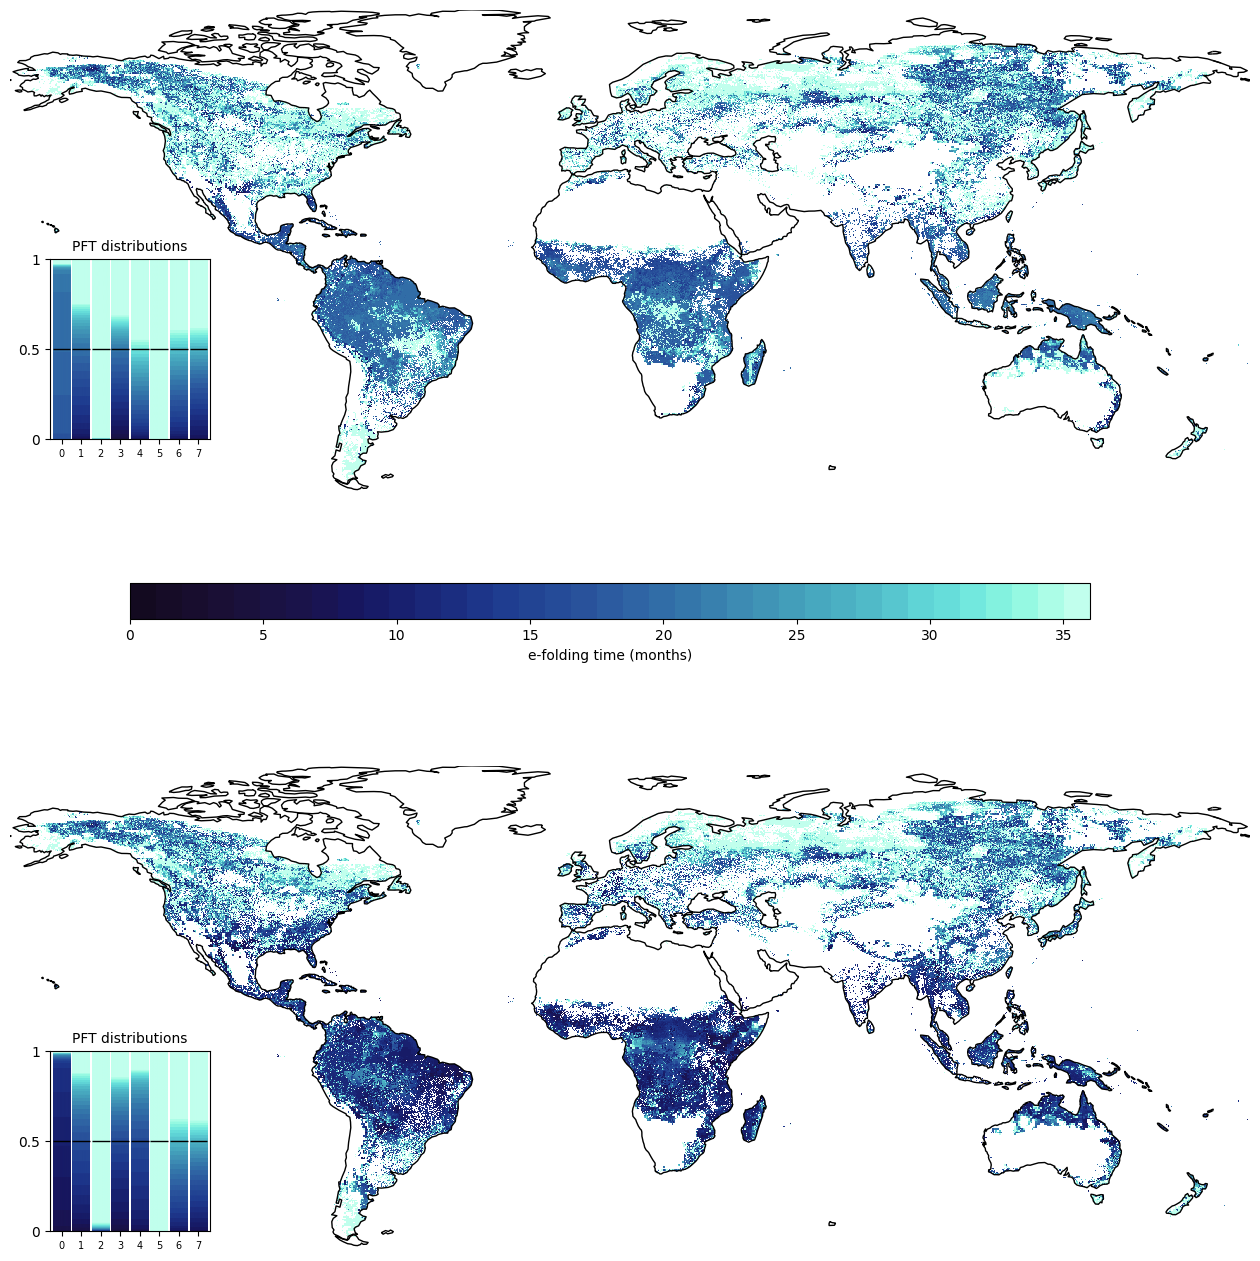

In [17]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import numpy as np


# -----------------------------
# Clean data
# -----------------------------
tau_base_clean = tau_base.where((tau_base > 0) & (tau_base < 120))
tau_DM_clean   = tau_DM.where((tau_DM > 0) & (tau_DM < 120))

pft_names = ['trop.EVG', 'trop.RG', 'temp.NE', 'temp.BE', 'temp.BS', 'boreal.NE', 'boreal.BS', 'boreal.NS']

pfts = tau_base_clean['pft'].values

norm = plt.Normalize(0, 36)

# -----------------------------
# Figure (maps)
# -----------------------------
fig, axes = plt.subplots(
    2, 1,
    figsize=(16, 18),
    subplot_kw={'projection': ccrs.PlateCarree(central_longitude=11)}
)

# --- maps ---
tau_base_mean.plot(
    ax=axes[0],
    transform=ccrs.PlateCarree(),
    vmin=0, vmax=36,
    cmap=cmap,
    add_colorbar=False
)

im = tau_DM_mean.plot(
    ax=axes[1],
    transform=ccrs.PlateCarree(),
    vmin=0, vmax=36,
    cmap=cmap,
    add_colorbar=False
)

for ax in axes:
    ax.coastlines()
    ax.set_title("")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_frame_on(False)
    
    ax.set_xlabel("")
    ax.set_ylabel("")

# -----------------------------
# inset helper
# -----------------------------
def plot_strips(ax, data):
    for i, pft in enumerate(pfts):
        vals = data.sel(pft=pft).values.flatten()
        vals = vals[~np.isnan(vals)]

        if len(vals) == 0:
            continue

        vals_sorted = np.sort(vals)
        strip = vals_sorted[:, None]

        ax.imshow(
            strip,
            aspect='auto',
            cmap=cmap,
            norm=norm,
            extent=(i - 0.45, i + 0.45, 0, 1),
            origin='lower'
        )

        median = np.median(vals_sorted)
        y_med = np.searchsorted(vals_sorted, median) / len(vals_sorted)

        ax.hlines(
            y=y_med,
            xmin=i - 0.45,
            xmax=i + 0.45,
            color='black',
            linewidth=1
        )

    ax.set_xlim(-0.6, len(pfts) - 0.4)
    ax.set_ylim(0, 1)
    ax.set_yticks([0, 0.5, 1])
    ax.set_yticklabels(["0", "0.5", "1"])
    ax.set_xticks(np.arange(len(pfts)))
    ax.set_xticklabels(pfts, fontsize=7)


# -----------------------------
# INSETS (ONE PER MAP)
# -----------------------------

# inset for baseline
inset1 = fig.add_axes([0.15, 0.60, 0.1, 0.1])  # top inset
plot_strips(inset1, tau_base_clean)
inset1.set_title("PFT distributions", fontsize=10)

# inset for drought
inset2 = fig.add_axes([0.15, 0.16, 0.1, 0.1])  # bottom inset
plot_strips(inset2, tau_DM_clean)
inset2.set_title("PFT distributions", fontsize=10)

# -----------------------------
# shared colorbar
# -----------------------------
cbar_ax = fig.add_axes([0.2, 0.5, 0.6, 0.02])
cbar = fig.colorbar(im, cax=cbar_ax, orientation='horizontal')
cbar.set_label("e-folding time (months)")

# -----------------------------
# styling
# -----------------------------
fig.patch.set_alpha(0)
for ax in axes:
    ax.set_facecolor("none")

inset1.set_facecolor("white")
inset2.set_facecolor("white")

plt.savefig(
    "tau_maps_with_two_insets.png",
    dpi=300,
    bbox_inches="tight",
    transparent=True
)

plt.show()

In [23]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import numpy as np

# --- clean data ---
tau_base_clean = tau_base.where((tau_base > 0) & (tau_base < 120))
tau_DM_clean   = tau_DM.where((tau_DM > 0) & (tau_DM < 120))

pfts = tau_base_clean['pft'].values

# --- projection centered over Europe ---
proj = ccrs.PlateCarree(central_longitude=11)

n_pft = len(pfts)

fig, axes = plt.subplots(
    nrows=2,
    ncols=n_pft,
    figsize=(3*n_pft, 6),
    subplot_kw={'projection': proj},
    constrained_layout=True
)

vmin, vmax = 0, 36

for i, pft in enumerate(pfts):

    # --- baseline per PFT ---
    tau_base_pft = tau_base_clean.sel(pft=pft)
    tau_DM_pft   = tau_DM_clean.sel(pft=pft)

    # --- baseline map ---
    im0 = tau_base_pft.plot(
        ax=axes[0, i],
        transform=ccrs.PlateCarree(),
        vmin=vmin, vmax=vmax,
        cmap=cmap,
        add_colorbar=False
    )
    axes[0, i].coastlines()
    axes[0, i].set_title(f"PFT {pft}")
    axes[0, i].set_xticks([])
    axes[0, i].set_yticks([])
    axes[0, i].set_frame_on(False)

    # --- drought map ---
    im1 = tau_DM_pft.plot(
        ax=axes[1, i],
        transform=ccrs.PlateCarree(),
        vmin=vmin, vmax=vmax,
        cmap=cmap,
        add_colorbar=False
    )
    axes[1, i].coastlines()
    axes[1, i].set_xticks([])
    axes[1, i].set_yticks([])
    axes[1, i].set_frame_on(False)

# --- row labels (clean instead of titles) ---
axes[0, 0].set_ylabel("Baseline", fontsize=12)
axes[1, 0].set_ylabel("Drought", fontsize=12)

# --- shared colorbar ---
cbar_ax = fig.add_axes([0.25, 0.05, 0.5, 0.02])
cbar = fig.colorbar(im1, cax=cbar_ax, orientation='horizontal')
cbar.set_label("τ")

# --- transparent background ---
fig.patch.set_alpha(0)
for ax in axes.flat:
    ax.set_facecolor("none")

plt.savefig("tau_pft_maps.png", dpi=300, bbox_inches="tight", transparent=True)
plt.show()

: 

/scratch-local/77370/ipykernel_2434855/3810340841.py:40: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


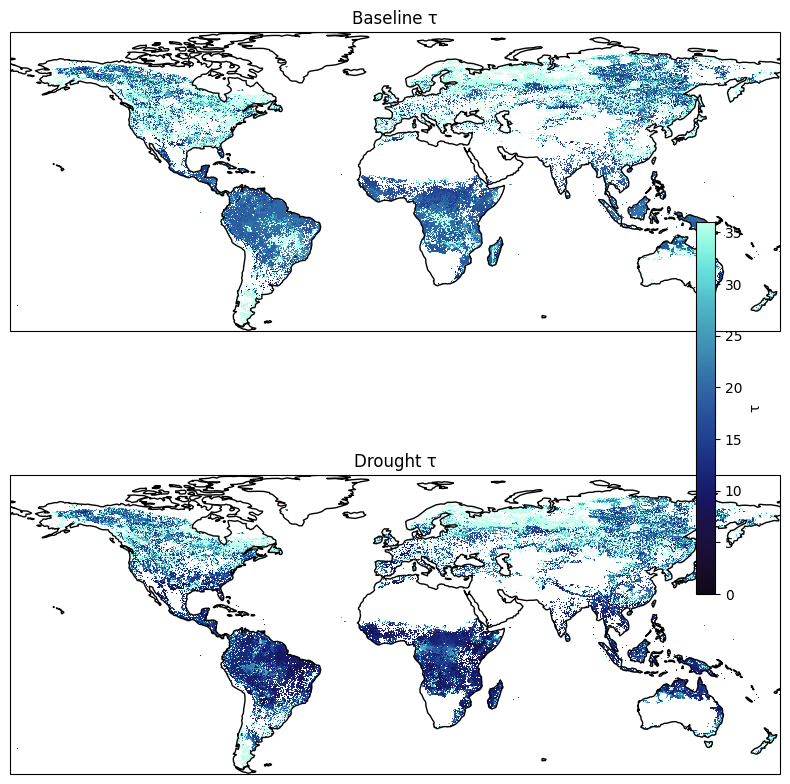

In [16]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs


cmap = cmaps.blue_bl111

# --- Figure with 2 rows ---
fig, axes = plt.subplots(
    nrows=2, ncols=1,
    figsize=(8, 10),
    subplot_kw={'projection': ccrs.PlateCarree()}
)

# --- Baseline map ---
tau_base_mean.plot(
    ax=axes[0],
    transform=ccrs.PlateCarree(),
    vmin=0, vmax=36,
    cmap=cmap,
    add_colorbar=False
)
axes[0].coastlines()
axes[0].set_title("Baseline τ")

# --- Drought map ---
im = tau_DM_mean.plot(
    ax=axes[1],
    transform=ccrs.PlateCarree(),
    vmin=0, vmax=36,
    cmap=cmap,
    add_colorbar=False
)
axes[1].coastlines()
axes[1].set_title("Drought τ")

# --- One shared colorbar ---
cbar = fig.colorbar(im, ax=axes, orientation='vertical', fraction=0.03, pad=0.02)
cbar.set_label("τ")

plt.tight_layout()
plt.show()

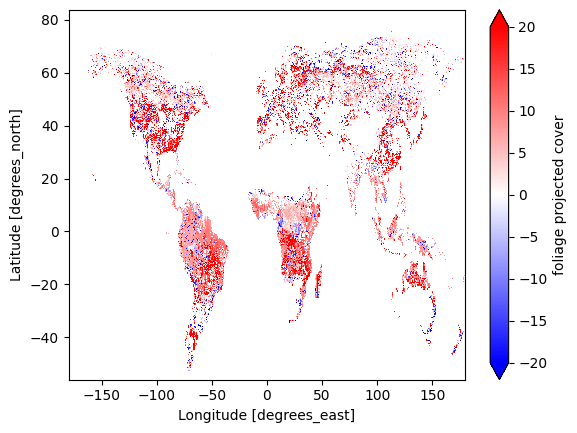

In [5]:
(tau_base_mean - tau_DM_mean).plot(vmin = -20, vmax = 20, cmap = 'bwr')

37.475224061972995


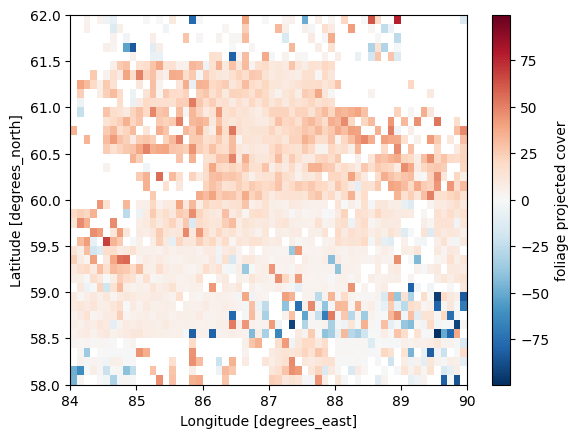

In [9]:
(tau_base_mean - tau_DM_mean).sel(lon = slice(84,90), lat = slice(58,62)).plot()
print((tau_base_mean - tau_DM_mean).sel(lon = 88.1, lat = 60.7,  method='nearest').values)

88.5515699328279


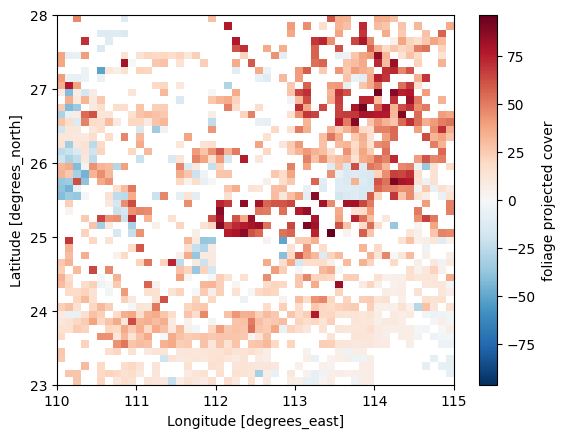

In [ ]:
(tau_base_mean - tau_DM_mean).sel(lon = slice(110,115), lat = slice(23,28)).plot()
print((tau_base_mean - tau_DM_mean).sel(lon = 112.1, lat = 25.1,  method='nearest').values)

43.49365996530237


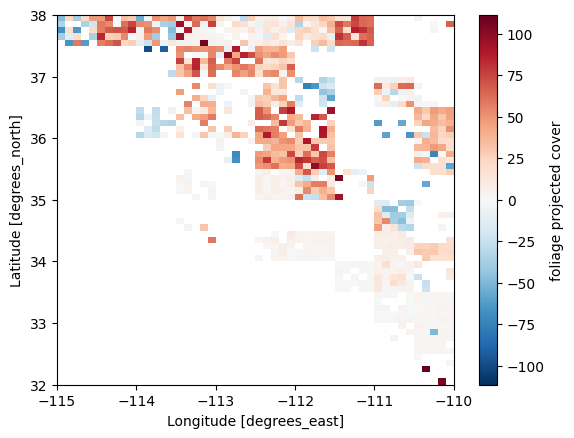

In [54]:
(tau_base_mean - tau_DM_mean).sel(lon = slice(-115,-110), lat = slice(32,38)).plot()
print((tau_base_mean - tau_DM_mean).sel(lon = -112, lat = 35.5,  method='nearest').values)

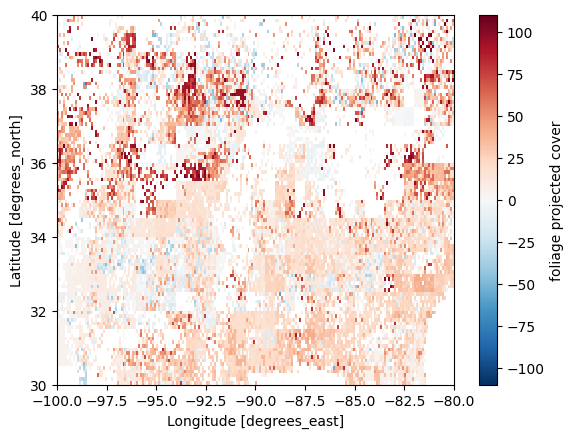

In [ ]:
(tau_base_mean - tau_DM_mean).sel(lon = slice(-100,-80), lat = slice(30,40)).plot()


In [47]:
(tau_base_mean - tau_DM_mean).sel(lon = -93, lat = 35.5,  method='nearest').values

array(90.8406343)

64.97038899429054


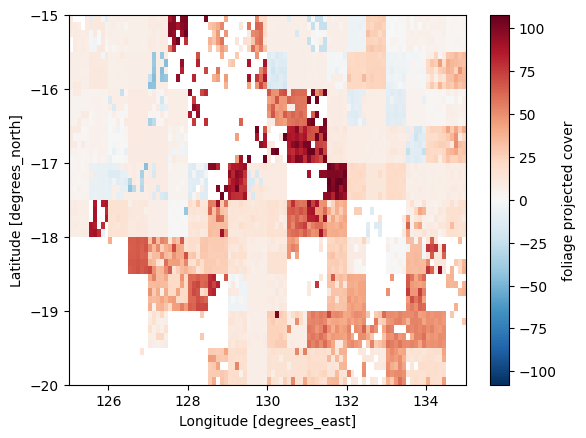

In [59]:
(tau_base_mean - tau_DM_mean).sel(lon = slice(125,135), lat = slice(-20,-15)).plot()
print((tau_base_mean - tau_DM_mean).sel(lon = 131, lat = -18,  method='nearest').values)

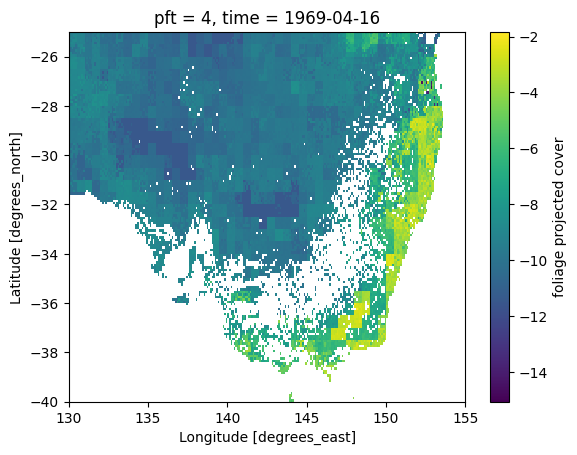

In [ ]:
import numpy as np
import xarray as xr


# avoid log(0)
FPC = fpc_proc['baseline'].where(fpc_proc['baseline'] > 0)

logFPC = np.log(FPC)


# # convert time to numeric (years)
# t = xr.DataArray(
#     (FPC['time'].dt.year + FPC['time'].dt.dayofyear / 365.0),
#     dims="time"
# )

# # subtract first time to avoid big numbers
# t = t - t.isel(time=0)

# linear regression: slope = -k
slope = xr.apply_ufunc(
    lambda x, y: np.polyfit(x, y, 1)[0],
    t, logFPC,
    input_core_dims=[["time"], ["time"]],
    vectorize=True,
    dask="parallelized",
    output_dtypes=[float]
)

# k = -slope
# tau = 1 / k   # e-folding time



In [31]:
import numpy as np
import xarray as xr

def compute_efolding(FPC):
    # avoid log(0)
    FPC = FPC.where(FPC > 0)

    logFPC = np.log(FPC)

    # convert time to numeric (years)
    t = xr.DataArray(
        (FPC['time'].dt.year + FPC['time'].dt.dayofyear / 365.0),
        dims="time"
    )

    # subtract first time to avoid big numbers
    t = t - t.isel(time=0)

    # linear regression: slope = -k
    slope = xr.apply_ufunc(
        lambda x, y: np.polyfit(x, y, 1)[0],
        t, logFPC,
        input_core_dims=[["time"], ["time"]],
        vectorize=True,
        dask="parallelized",
        output_dtypes=[float]
    )

    k = -slope
    tau = 1 / k   # e-folding time

    return tau

In [48]:
tau_base = compute_efolding(fpc_proc['baseline'])
tau_base

<xarray.DataArray (pft: 8, lat: 150, lon: 250)> Size: 2MB
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
...
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]], shape=(8, 150, 250))
Coordinates:
  * pft      (pft) int32 32B 0 1 2 3 4 5 6 7
  * lat      (lat) float64 1kB -39.95 -39.85 -39.75 ... -25.25 -25.15 -25.05
  * lon      (lon) float64 2kB 130.1 130.2 130.3 130.4 ... 154.8 154.9 155.0
Attributes:
    standard_name:  time
    long_name:      Time
    axis:           T

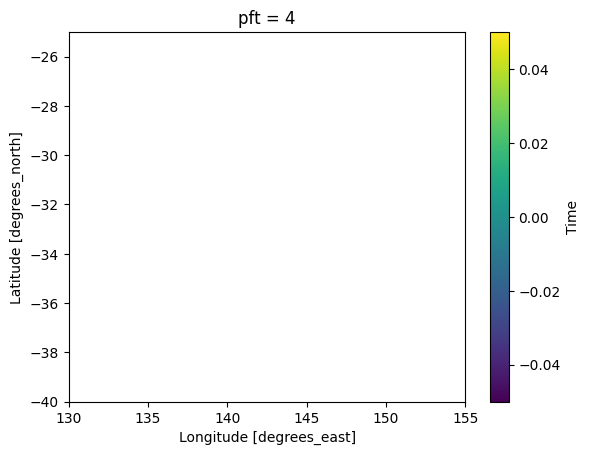

In [50]:
tau_base[4].plot()

In [49]:
tau_DM   = compute_efolding(fpc_proc['DM'])
tau_DM

<xarray.DataArray (pft: 8, lat: 150, lon: 250)> Size: 2MB
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
...
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]], shape=(8, 150, 250))
Coordinates:
  * pft      (pft) int32 32B 0 1 2 3 4 5 6 7
  * lat      (lat) float64 1kB -39.95 -39.85 -39.75 ... -25.25 -25.15 -25.05
  * lon      (lon) float64 2kB 130.1 130.2 130.3 130.4 ... 154.8 154.9 155.0
Attributes:
    standard_name:  time
    long_name:      Time
    axis:           T

In [34]:
valid_pfts = [
    "tropical broadleaved evergreen tree",
    "tropical broadleaved raingreen tree",
    "temperate needleleaved evergreen tree",
    "temperate broadleaved evergreen tree",
    "temperate broadleaved summergreen tree",
    "boreal needleleaved evergreen tree",
    "boreal broadleaved summergreen tree",
    "boreal needleleaved summergreen tree",
]

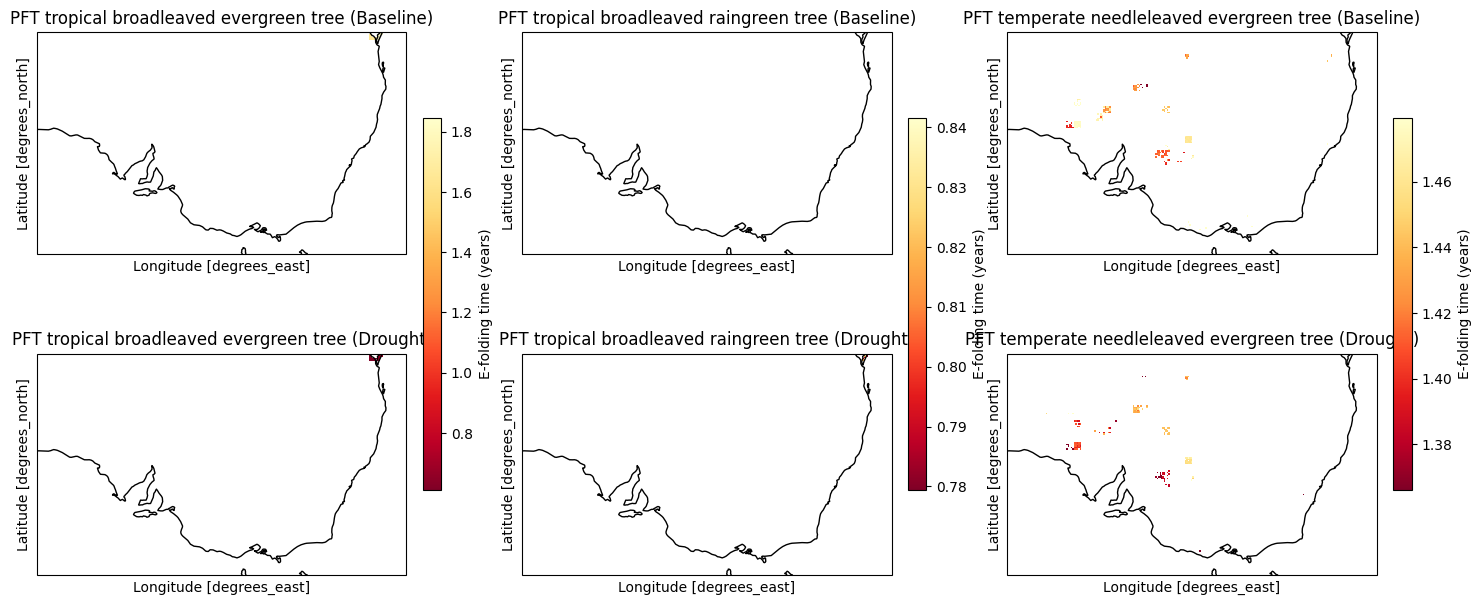

In [35]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import numpy as np

def plot_pft_comparison_autoscale(tau_base, tau_DM, valid_pfts):
    n = len(valid_pfts)
    ncols = min(4, n)
    nrows = int(np.ceil(n / ncols))

    fig = plt.figure(figsize=(6*ncols, 8*nrows))

    for i, pft in enumerate(valid_pfts):
        row = i // ncols
        col = i % ncols
        
        base = tau_base.sel(pft=i)
        dm   = tau_DM.sel(pft=i)

        # --- compute shared vmin/vmax for THIS PFT ---
        combined = np.concatenate([
            base.values.flatten(),
            dm.values.flatten()
        ])

        combined = combined[np.isfinite(combined)]

        if len(combined) == 0:
            continue

        # robust scaling (avoids outliers blowing up colorbar)
        vmin = np.percentile(combined, 5)
        vmax = np.percentile(combined, 95)

        # --- TOP: baseline ---
        ax_top = plt.subplot(
            2*nrows, ncols, 2*row*ncols + col + 1,
            projection=ccrs.PlateCarree()
        )

        im = base.plot(
            ax=ax_top,
            transform=ccrs.PlateCarree(),
            cmap="YlOrRd_r",
            vmin=vmin, vmax=vmax,
            add_colorbar=False
        )

        ax_top.coastlines()
        ax_top.set_title(f"PFT {pft} (Baseline)")
        ax_top.set_xticks([])
        ax_top.set_yticks([])

        # --- BOTTOM: drought ---
        ax_bot = plt.subplot(
            2*nrows, ncols, (2*row+1)*ncols + col + 1,
            projection=ccrs.PlateCarree()
        )

        dm.plot(
            ax=ax_bot,
            transform=ccrs.PlateCarree(),
            cmap="YlOrRd_r",
            vmin=vmin, vmax=vmax,
            add_colorbar=False
        )

        ax_bot.coastlines()
        ax_bot.set_title(f"PFT {pft} (Drought)")
        ax_bot.set_xticks([])
        ax_bot.set_yticks([])

        # --- shared colorbar per PFT ---
        cbar = fig.colorbar(
            im,
            ax=[ax_top, ax_bot],
            orientation="vertical",
            fraction=0.046,
            pad=0.04
        )
        cbar.set_label("E-folding time (years)")

    #plt.tight_layout()
    plt.show()
    
plot_pft_comparison_autoscale(tau_base, tau_DM, valid_pfts)

In [ ]:
gpp = load_all_runs("pft_gpp", "GPP")

def process_gpp_per_pft(data):
    return data.sel(pft=slice(1, 12)).convert_calendar("standard")

# process all scenarios automatically
gpp_proc = {name: process_gpp_per_pft(ds) for name, ds in gpp.items()}
gpp_proc

In [ ]:
valid_pfts = []
for pft in list(gpp_proc.values())[0].pft.values:
    combined = np.concatenate([
        gpp_proc[name].sel(pft=pft).values for name in gpp_proc
    ])
    
    if not (np.all(np.isnan(combined)) or np.all(np.isclose(combined, 0))):
        valid_pfts.append(pft)

In [ ]:
gpp = load_all_runs("pft_gpp", "GPP")

In [ ]:
fpc = load_all_runs("fpc", "FPC")

baseline_nodrought_FPC = fpc["baseline_nodrought"]
DM_nodrought_FPC = fpc["DM_nodrought"]

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def process_gpp_per_pft(data):
    return data.sel(pft=slice(1, 12)).convert_calendar("standard")

# process all scenarios automatically
gpp_proc = {name: process_gpp_per_pft(ds) for name, ds in gpp.items()}

# find valid PFTs
valid_pfts = []
for pft in list(gpp_proc.values())[0].pft.values:
    combined = np.concatenate([
        gpp_proc[name].sel(pft=pft).values for name in gpp_proc
    ])
    
    if not (np.all(np.isnan(combined)) or np.all(np.isclose(combined, 0))):
        valid_pfts.append(pft)

# create subplots dynamically
n = len(valid_pfts)
fig, axes = plt.subplots(n, 1, figsize=(12, 2.5*n), sharex=True)
axes = np.atleast_1d(axes)

for i, pft in enumerate(valid_pfts):
    ax = axes[i]

    for name, data in gpp_proc.items():
        if name.endswith("nodrought"):
            linestyle = "-"      # solid for no drought
        elif name.endswith("drought"):
            linestyle = "--"     # dashed for drought
        else:
            linestyle = "-"      # fallback
        ax.plot(data.time, data.sel(pft=pft), linestyle=linestyle, label=name)

    ax.set_title(f"PFT {pft}", loc="left")
    ax.grid(alpha=0.3)

# labels
fig.supxlabel("Time")
fig.supylabel("GPP (gC/m²/month)")
fig.suptitle("GPP per active PFT (1–12), Spatial Mean")

# legend once
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Load FPC for all scenarios
fpc = load_all_runs("fpc", "FPC")

# process function: skip total PFT (first), spatial mean
def process_fpc_per_pft(data):
    return data.sel(pft=slice(2, 12)).convert_calendar("standard")

# process all scenarios
fpc_proc = {name: process_fpc_per_pft(ds) for name, ds in fpc.items()}

# determine valid PFTs (non-empty)
valid_pfts = []
for pft in list(fpc_proc.values())[0].pft.values:
    combined = np.concatenate([fpc_proc[name].sel(pft=pft).values for name in fpc_proc])
    if not (np.all(np.isnan(combined)) or np.all(np.isclose(combined, 0))):
        valid_pfts.append(pft)

# create dynamic vertical subplots
n = len(valid_pfts)
fig, axes = plt.subplots(n, 1, figsize=(12, 2.5*n), sharex=True)
axes = np.atleast_1d(axes)

for i, pft in enumerate(valid_pfts):
    ax = axes[i]
    
    for name, data in fpc_proc.items():
        if name.endswith("nodrought"):
            linestyle = "-"      # solid for no drought
        elif name.endswith("drought"):
            linestyle = "--"     # dashed for drought
        else:
            linestyle = "-"      # fallback
        ax.plot(data.time, data.sel(pft=pft), linestyle=linestyle, label=name)
    
    ax.set_title(f"PFT {pft - 1}", loc="left")  # subtract 1 because we skipped the total
    ax.grid(alpha=0.3)

# labels and title
fig.supxlabel("Time")
fig.supylabel("FPC")
fig.suptitle("FPC per active PFT (2–12), Spatial Mean (skipping total)")

# legend once
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Load NIND for all scenarios
nind = load_all_runs("pft_nind", "nind")

# processing function: first 12 PFTs, spatial mean
def process_nind_per_pft(data):
    return data.sel(pft=slice(1, 12)).convert_calendar("standard")

# process all scenarios
nind_proc = {}
for name, ds in nind.items():
    proc = process_nind_per_pft(ds)
    
    # if baseline runs, sum monthly -> yearly
    if "baseline" in name:
        proc = proc.resample(time="YS").sum()
    
    nind_proc[name] = proc

# determine valid PFTs (non-empty)
valid_pfts = []
for pft in list(nind_proc.values())[0].pft.values:
    combined = np.concatenate([nind_proc[name].sel(pft=pft).values for name in nind_proc])
    if not (np.all(np.isnan(combined)) or np.all(np.isclose(combined, 0))):
        valid_pfts.append(pft)

# create vertical subplots dynamically
n = len(valid_pfts)
fig, axes = plt.subplots(n, 1, figsize=(12, 2.5*n), sharex=True)
axes = np.atleast_1d(axes)

for i, pft in enumerate(valid_pfts):
    ax = axes[i]
    
    for name, data in nind_proc.items():
        # precise linestyle: solid = no drought, dashed = drought
        if name.endswith("nodrought"):
            linestyle = "-"
        elif name.endswith("drought"):
            linestyle = "--"
        else:
            linestyle = "-"
        ax.plot(data.time, data.sel(pft=pft), linestyle=linestyle, label=name)
    
    ax.set_title(f"PFT {pft}", loc="left")
    ax.grid(alpha=0.3)

# labels and title
fig.supxlabel("Time")
fig.supylabel("NIND")
fig.suptitle("NIND per active PFT (1–12), Spatial Mean")

# legend once
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [ ]:
valid_pfts = []
for pft in list(gpp_proc.values())[0].pft.values:
    combined = np.concatenate([
        gpp_proc[name].sel(pft=pft).values for name in gpp_proc
    ])
    
    if not (np.all(np.isnan(combined)) or np.all(np.isclose(combined, 0))):
        valid_pfts.append(pft)

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm

runs = list(gpp_proc.keys())

pft_names = [
    'tropical broadleaved evergreen tree',
    'tropical broadleaved raingreen tree',
    'temperate needleleaved evergreen tree',
    'temperate broadleaved evergreen tree',
    'temperate broadleaved summergreen tree',
    'boreal needleleaved evergreen tree',
    'boreal broadleaved summergreen tree',
    'boreal needleleaved summergreen tree',
    'Tropical C4 grass',
    'Temperate C3 grass',
    'Polar C3 grass'
]

all_pfts = nind_proc[list(nind_proc.keys())[0]].pft.values

# map each PFT value to its name based on position
pft_labels = {
    pft: pft_names[int(pft) - 1]
    for pft in all_pfts
}

# define consistent colors for each PFT
# ---- PFT groups ----
tropical = [1, 2]
temperate = [3, 4, 5]
boreal = [6, 7, 8]
grass = [9, 10, 11]

import matplotlib.cm as cm
import numpy as np

pft_colors = {}

# gradients per group
greens = cm.Greens(np.linspace(0.5, 0.9, len(tropical)))
oranges = cm.Oranges(np.linspace(0.5, 0.9, len(temperate)))
blues = cm.Blues(np.linspace(0.5, 0.9, len(boreal)))
yellows = cm.Purples(np.linspace(0.4, 0.8, len(grass)))

# assign colors
for i, p in enumerate(tropical):
    pft_colors[p] = greens[i]

for i, p in enumerate(temperate):
    pft_colors[p] = oranges[i]

for i, p in enumerate(boreal):
    pft_colors[p] = blues[i]

for i, p in enumerate(grass):
    pft_colors[p] = yellows[i]


fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

selected_runs = runs[3:6]  # pick exactly 3 runs

for ax, run in zip(axes, selected_runs):
    data = gpp_proc[run]
    
    years = data.time.values
    
    # collect data per PFT
    stack_data = []
    labels = []
    colors = []
    
    for pft in valid_pfts:
        vals = data.sel(pft=pft).values
        stack_data.append(vals)
        labels.append(pft_labels[pft])
        colors.append(pft_colors[pft])
    
    # stacked area plot
    ax.stackplot(years, stack_data, labels=labels, colors=colors)
    
    ax.set_title(run, loc="left")
    ax.set_ylabel("GPP")
    ax.grid(alpha=0.3)
    ax.set_ylim(0, 175)  

# shared x-label
axes[-1].set_xlabel("Year")

# legend (only once)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="center right")

plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm

runs = list(nind_proc.keys())

pft_names = [
    'tropical broadleaved evergreen tree',
    'tropical broadleaved raingreen tree',
    'temperate needleleaved evergreen tree',
    'temperate broadleaved evergreen tree',
    'temperate broadleaved summergreen tree',
    'boreal needleleaved evergreen tree',
    'boreal broadleaved summergreen tree',
    'boreal needleleaved summergreen tree',
    'Tropical C4 grass',
    'Temperate C3 grass',
    'Polar C3 grass'
]

all_pfts = nind_proc[list(nind_proc.keys())[0]].pft.values

# map each PFT value to its name based on position
pft_labels = {
    pft: pft_names[int(pft) - 1]
    for pft in all_pfts
}

# define consistent colors for each PFT
# ---- PFT groups ----
tropical = [1, 2]
temperate = [3, 4, 5]
boreal = [6, 7, 8]
grass = [9, 10, 11]

import matplotlib.cm as cm
import numpy as np

pft_colors = {}

# gradients per group
greens = cm.Greens(np.linspace(0.5, 0.9, len(tropical)))
oranges = cm.Oranges(np.linspace(0.5, 0.9, len(temperate)))
blues = cm.Blues(np.linspace(0.5, 0.9, len(boreal)))
yellows = cm.Purples(np.linspace(0.4, 0.8, len(grass)))

# assign colors
for i, p in enumerate(tropical):
    pft_colors[p] = greens[i]

for i, p in enumerate(temperate):
    pft_colors[p] = oranges[i]

for i, p in enumerate(boreal):
    pft_colors[p] = blues[i]

for i, p in enumerate(grass):
    pft_colors[p] = yellows[i]


fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

selected_runs = runs[3:6]  # pick exactly 3 runs

for ax, run in zip(axes, selected_runs):
    data = nind_proc[run]
    
    years = data.time.values
    
    # collect data per PFT
    stack_data = []
    labels = []
    colors = []
    
    for pft in valid_pfts:
        vals = data.sel(pft=pft).values
        stack_data.append(vals)
        labels.append(pft_labels[pft])
        colors.append(pft_colors[pft])
    
    # stacked area plot
    ax.stackplot(years, stack_data, labels=labels, colors=colors)
    
    ax.set_title(run, loc="left")
    ax.set_ylabel("NIND")
    ax.grid(alpha=0.3)
    ax.set_ylim(0, 2.5)

# shared x-label
axes[-1].set_xlabel("Year")

# legend (only once)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="center right")

plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm

runs = list(fpc_proc.keys())

pft_names = [
    'tropical broadleaved evergreen tree',
    'tropical broadleaved raingreen tree',
    'temperate needleleaved evergreen tree',
    'temperate broadleaved evergreen tree',
    'temperate broadleaved summergreen tree',
    'boreal needleleaved evergreen tree',
    'boreal broadleaved summergreen tree',
    'boreal needleleaved summergreen tree',
    'Tropical C4 grass',
    'Temperate C3 grass',
    'Polar C3 grass'
]

all_pfts = fpc_proc[list(fpc_proc.keys())[0]].pft.values

# map each PFT value to its name based on position
pft_labels = {
    pft: pft_names[int(pft) - 2]
    for pft in all_pfts
}

# define consistent colors for each PFT
# ---- PFT groups ----
tropical = [2, 3]
temperate = [4, 5, 6]
boreal = [7, 8, 9]
grass = [10, 11, 12]

import matplotlib.cm as cm
import numpy as np

pft_colors = {}

# gradients per group
greens = cm.Greens(np.linspace(0.5, 0.9, len(tropical)))
oranges = cm.Oranges(np.linspace(0.5, 0.9, len(temperate)))
blues = cm.Blues(np.linspace(0.5, 0.9, len(boreal)))
yellows = cm.Purples(np.linspace(0.4, 0.8, len(grass)))

# assign colors
for i, p in enumerate(tropical):
    pft_colors[p] = greens[i]

for i, p in enumerate(temperate):
    pft_colors[p] = oranges[i]

for i, p in enumerate(boreal):
    pft_colors[p] = blues[i]

for i, p in enumerate(grass):
    pft_colors[p] = yellows[i]


fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

selected_runs = runs[3:6]  # pick exactly 3 runs

for ax, run in zip(axes, selected_runs):
    data = fpc_proc[run]
    
    years = data.time.values
    
    # collect data per PFT
    stack_data = []
    labels = []
    colors = []
    
    for pft in valid_pfts:
        vals = data.sel(pft=pft).values
        stack_data.append(vals)
        labels.append(pft_labels[pft])
        colors.append(pft_colors[pft])
    
    # stacked area plot
    ax.stackplot(years, stack_data, labels=labels, colors=colors)
    
    ax.set_title(run, loc="left")
    ax.set_ylabel("FPC")
    ax.grid(alpha=0.3)

# shared x-label
axes[-1].set_xlabel("Year")

# legend (only once)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="center right")

plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.savefig(
    "/home/druijsch/LPJmL5/dev15oct2025/config_files/2026_04_07_drought_experiment/10years/2026_04_20_tenyeardrought_FPC.png",
    dpi=300,
    bbox_inches="tight",
    transparent=True
)
plt.show()